In [27]:
import os
from PIL import Image
img = Image.open("cat_dog dataset/PetImages/cat/0.jpg")
print(img.size)
print(img.mode)

(500, 375)
RGB


In [28]:
#dataloaders

from torchvision import datasets
from torchvision.transforms import transforms
from torch.utils.data import DataLoader,random_split

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(
    "cat_dog dataset/PetImages",
    transform=train_transform
)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = int(len(dataset) - train_size - val_size)

train_dataset ,val_dataset, test_dataset = random_split(dataset , [train_size, val_size, test_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)



1
{'Cat': 0, 'Dog': 1}


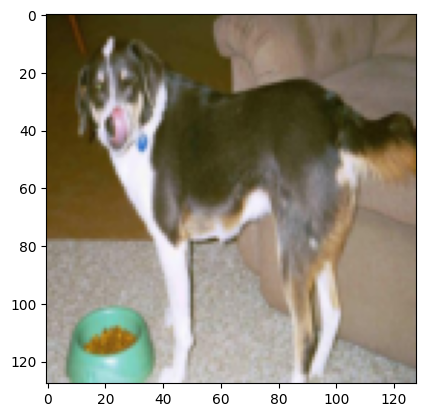

In [29]:
#verifying labels

import matplotlib.pyplot as plt

image,label = train_dataset[200]
plt.imshow(image.permute(1,2,0))  # rearranges the dimesion of image ( H, W , C) from pytorch's dimension ( C , H , W)
print(label)
print(dataset.class_to_idx)

In [30]:
#model 
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size = 2 , stride = 2),

            nn.Conv2d(32,64,3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size = 2 , stride = 2),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.classifier(x)

        return x


In [32]:
#training
import torch.optim as optim
import torch

model = CNN()

learning_rate = 0.01

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

epoch = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.train()

for iteration in range(epoch):
    running_loss = 0
    correct = 0
    total = 0
    
    for images,labels in train_loader :
        images,labels = images.to(device),labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

    accuracy = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {iteration+1}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")


Epoch 1
Loss: 0.6622
Accuracy: 60.05%
Epoch 2
Loss: 0.6162
Accuracy: 66.07%
Epoch 3
Loss: 0.5917
Accuracy: 68.60%
Epoch 4
Loss: 0.5762
Accuracy: 69.61%
Epoch 5
Loss: 0.5669
Accuracy: 70.85%
Epoch 6
Loss: 0.5575
Accuracy: 71.18%
Epoch 7
Loss: 0.5487
Accuracy: 72.03%
Epoch 8
Loss: 0.5423
Accuracy: 72.89%
Epoch 9
Loss: 0.5306
Accuracy: 73.62%
Epoch 10
Loss: 0.5250
Accuracy: 73.67%
